# YOLO на маленьком butterfly goldenset

Цель ноутбука простая: показать, что на маленьком датасете YOLO учится плохо.
Мы хотим увидеть две вещи:

1. loss по эпохам не показывает уверенного улучшения;
2. после обучения качество на тесте остаётся низким.


In [1]:
import json
import shutil
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import yaml
from IPython.display import clear_output, display
from PIL import Image
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
RANDOM_STATE = 42
TEST_SIZE = 0.2
EPOCHS = 30
IMAGE_SIZE = 640
BATCH_SIZE = 4
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.5

print("DEVICE =", DEVICE)


DEVICE = mps


## Подготовка данных


,group,rows
0,all usable rows,137
1,positive butterfly with bbox,57
2,negative images,80


,entity,count
0,butterfly,57
1,flower,20
2,beetle,20
3,bee,20
4,shrub,20


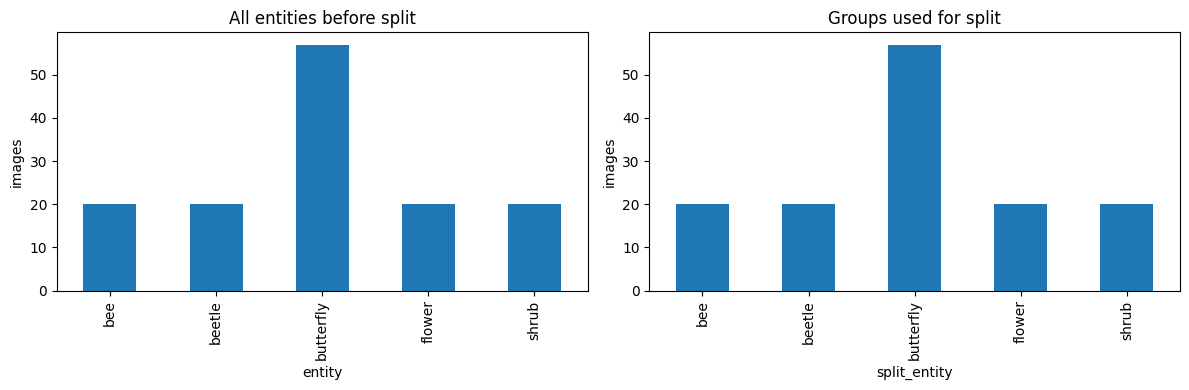

,split,rows,positives,negatives
0,train,109,45,64
1,test,28,12,16


,train,test
entity,,
bee,16,4
beetle,16,4
butterfly,45,12
flower,16,4
shrub,16,4


In [2]:
df = pd.DataFrame(json.loads(Path("goldenset.json").read_text()))

df["has_bbox"] = df["bbox"].notna()
df["is_butterfly"] = df["entity"].eq("butterfly")
df["is_positive"] = df["is_butterfly"] & df["has_bbox"]
df["is_negative"] = ~df["is_positive"]

model_df = df.loc[~(df["is_butterfly"] & ~df["has_bbox"])].copy().reset_index(drop=True)
model_df["split_entity"] = np.where(model_df["is_positive"], "butterfly", model_df["entity"])

summary = pd.DataFrame(
    [
        {"group": "all usable rows", "rows": len(model_df)},
        {"group": "positive butterfly with bbox", "rows": int(model_df["is_positive"].sum())},
        {"group": "negative images", "rows": int(model_df["is_negative"].sum())},
    ]
)
display(summary)

display(model_df["entity"].value_counts().rename_axis("entity").reset_index(name="count"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
model_df["entity"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="All entities before split")
axes[0].set_ylabel("images")
model_df["split_entity"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Groups used for split")
axes[1].set_ylabel("images")
plt.tight_layout()
plt.show()

train_df, test_df = train_test_split(
    model_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=model_df["split_entity"],
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

display(
    pd.DataFrame(
        [
            {
                "split": "train",
                "rows": len(train_df),
                "positives": int(train_df["is_positive"].sum()),
                "negatives": int(train_df["is_negative"].sum()),
            },
            {
                "split": "test",
                "rows": len(test_df),
                "positives": int(test_df["is_positive"].sum()),
                "negatives": int(test_df["is_negative"].sum()),
            },
        ]
    )
)

display(
    pd.concat(
        {
            "train": train_df["entity"].value_counts().sort_index(),
            "test": test_df["entity"].value_counts().sort_index(),
        },
        axis=1,
    ).fillna(0).astype(int)
)


In [3]:
def image_filename(row) -> str:
    suffix = Path(urlparse(row.image).path).suffix or ".jpg"
    return f"{row.photo_id}{suffix}"


downloads_dir = Path("tuning/downloads")
full_df = pd.concat([train_df, test_df], ignore_index=True).drop_duplicates(subset=["photo_id"])

local_path_map = {}
for row in full_df.itertuples(index=False):
    image_path = downloads_dir / image_filename(row)
    if not image_path.exists():
        response = requests.get(row.image, timeout=120)
        response.raise_for_status()
        image_path.write_bytes(response.content)
    local_path_map[row.photo_id] = str(image_path)

train_df["local_image"] = train_df["photo_id"].map(local_path_map)
test_df["local_image"] = test_df["photo_id"].map(local_path_map)

print("cached images:", len(full_df))
print("train images:", len(train_df))
print("test images:", len(test_df))


cached images: 137
train images: 109
test images: 28


## Подготовка YOLO-датасета


In [4]:
def bbox_to_yolo_line(bbox: dict) -> str:
    x_center = bbox["left"] + bbox["width"] / 2
    y_center = bbox["top"] + bbox["height"] / 2
    return f"0 {x_center:.6f} {y_center:.6f} {bbox['width']:.6f} {bbox['height']:.6f}"


dataset_dir = Path("dataset")
shutil.rmtree(dataset_dir, ignore_errors=True)

for split_name, split_df in [("train", train_df), ("test", test_df)]:
    image_dir = dataset_dir / "images" / split_name
    label_dir = dataset_dir / "labels" / split_name
    image_dir.mkdir(parents=True)
    label_dir.mkdir(parents=True)

    for row in split_df.itertuples(index=False):
        src = Path(row.local_image)
        shutil.copy2(src, image_dir / src.name)

        label_path = label_dir / f"{src.stem}.txt"
        if row.is_positive:
            label_path.write_text(bbox_to_yolo_line(row.bbox) + "\n", encoding="utf-8")
        else:
            label_path.write_text("", encoding="utf-8")

Path("dataset/data.yaml").write_text(yaml.safe_dump({
    "path": str(dataset_dir.resolve()),
    "train": "images/train",
    "val": "images/test",
    "names": {0: "butterfly"},
}, sort_keys=False))

print(Path("dataset/data.yaml").read_text())


path: /Users/mvsevolod/projects/aiconf-butterflies-segmentation/tuning/dataset
train: images/train
val: images/test
names:
  0: butterfly



## Обучение


,epoch,box_loss,cls_loss,dfl_loss
0,1,1.63783,5.96337,1.77553
1,2,1.94051,6.92129,2.07300
2,3,1.84163,5.01432,1.93216
3,4,2.16867,7.88343,2.17394
4,5,2.15801,6.08692,2.22091
5,6,2.27513,5.60600,2.35334
6,7,2.65762,5.65345,2.74629
7,8,2.40316,5.86335,2.59065
8,9,2.18275,6.94220,2.12839
9,10,2.31029,5.56039,2.37143


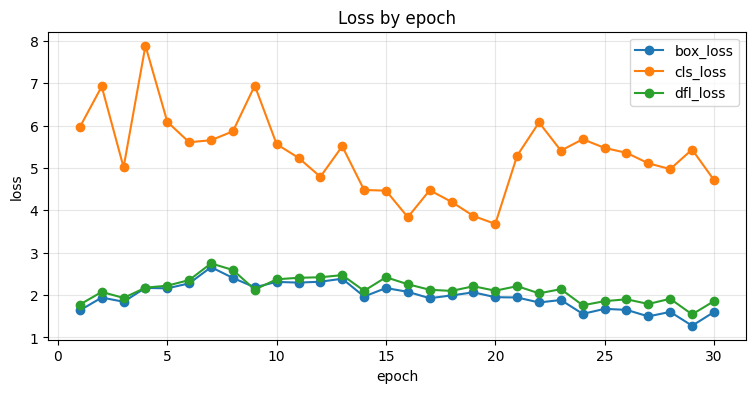

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.8it/s 2.2s1.0s
                   all         28         12    0.00107       0.75     0.0122    0.00516

30 epochs completed in 0.169 hours.
Optimizer stripped from /Users/mvsevolod/projects/aiconf-butterflies-segmentation/runs/detect/runs/small_goldenset_demo/weights/last.pt, 6.2MB
Optimizer stripped from /Users/mvsevolod/projects/aiconf-butterflies-segmentation/runs/detect/runs/small_goldenset_demo/weights/best.pt, 6.2MB

Validating /Users/mvsevolod/projects/aiconf-butterflies-segmentation/runs/detect/runs/small_goldenset_demo/weights/best.pt...
Ultralytics 8.4.24 🚀 Python-3.12.7 torch-2.10.0 CPU (Apple M2)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.9it/s 2.1s0.9s
                   all         28         12    0.00107     

In [5]:
loss_history = []


def refresh_loss_plot(trainer):
    loss_row = trainer.label_loss_items(trainer.tloss, prefix="train")
    loss_history.append({
        "epoch": trainer.epoch + 1,
        "box_loss": float(loss_row.get("train/box_loss", np.nan)),
        "cls_loss": float(loss_row.get("train/cls_loss", np.nan)),
        "dfl_loss": float(loss_row.get("train/dfl_loss", np.nan)),
    })

    plot_df = pd.DataFrame(loss_history)
    clear_output(wait=True)
    display(plot_df)

    ax = plot_df.plot(x="epoch", y=["box_loss", "cls_loss", "dfl_loss"], figsize=(9, 4), marker="o")
    ax.set_title("Loss by epoch")
    ax.set_ylabel("loss")
    ax.grid(alpha=0.3)
    plt.show()


model = YOLO("yolov8n.pt")
model.add_callback("on_train_epoch_end", refresh_loss_plot)

try:
    train_results = model.train(
        data="dataset/data.yaml",
        epochs=EPOCHS,
        imgsz=IMAGE_SIZE,
        batch=BATCH_SIZE,
        device=DEVICE,
        project="runs",
        name="small_goldenset_demo",
        exist_ok=True,
        plots=True,
        val=False,
        amp=False,
        workers=0,
    )
    train_device = DEVICE
except RuntimeError as exc:
    if DEVICE == "mps" and "Dimension size must be non-negative" in str(exc):
        print("MPS сломался внутри Ultralytics, повторяем на CPU")
        loss_history = []
        model = YOLO("yolov8n.pt")
        model.add_callback("on_train_epoch_end", refresh_loss_plot)
        train_results = model.train(
            data="dataset/data.yaml",
            epochs=EPOCHS,
            imgsz=IMAGE_SIZE,
            batch=BATCH_SIZE,
            device="cpu",
            project="runs",
            name="small_goldenset_demo",
            exist_ok=True,
            plots=True,
            val=False,
            amp=False,
            workers=0,
        )
        train_device = "cpu"
    else:
        raise

run_dir = Path(train_results.save_dir)
print("train_device =", train_device)
print("run_dir =", run_dir)


## Проверяем, что качество после обучения низкое


,metric,value
0,image_precision,1.000000
1,image_recall,0.083333
2,localized_recall_iou_0.5,0.000000
3,tp_images,1.000000
4,fp_images,0.000000
5,fn_images,11.000000
6,tn_images,16.000000
7,localized_tp_images,0.000000


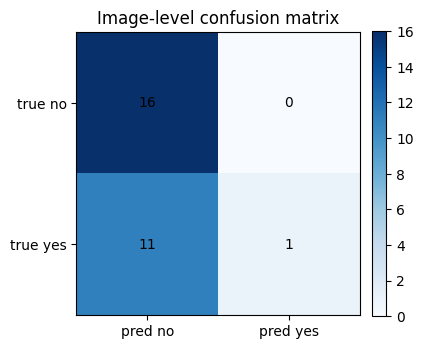

,photo_id,entity,is_positive,pred_has_box,best_iou,is_localized
0,620221919,butterfly,True,False,0.0,False
1,623075275,butterfly,True,False,0.0,False
2,624034537,butterfly,True,False,0.0,False
3,622591605,butterfly,True,False,0.0,False
4,624339783,beetle,False,False,NaN,False
5,621539026,butterfly,True,False,0.0,False
6,624279025,beetle,False,False,NaN,False
7,538336942,flower,False,False,NaN,False
8,535525351,flower,False,False,NaN,False
9,623106436,bee,False,False,NaN,False


In [7]:
def gt_box_to_xyxy(bbox: dict, image_size: tuple[int, int]):
    if not isinstance(bbox, dict):
        return None
    width, height = image_size
    return [
        bbox["left"] * width,
        bbox["top"] * height,
        (bbox["left"] + bbox["width"]) * width,
        (bbox["top"] + bbox["height"]) * height,
    ]


def iou(box_a, box_b) -> float:
    if box_a is None or box_b is None:
        return 0.0
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union else 0.0


predictions = []
results = best_model.predict(
    source=test_df["local_image"].tolist(),
    conf=CONF_THRESHOLD,
    device=train_device,
    verbose=False,
)

for row, result in zip(test_df.itertuples(index=False), results):
    image_size = Image.open(row.local_image).size
    gt_box = gt_box_to_xyxy(row.bbox, image_size)
    pred_boxes = [[float(v) for v in box.xyxy[0].tolist()] for box in result.boxes]
    pred_has_box = len(pred_boxes) > 0
    best_iou = max((iou(gt_box, pred_box) for pred_box in pred_boxes), default=0.0) if row.is_positive else np.nan
    is_localized = bool(row.is_positive and best_iou >= IOU_THRESHOLD)

    predictions.append(
        {
            "photo_id": row.photo_id,
            "entity": row.entity,
            "is_positive": bool(row.is_positive),
            "pred_has_box": pred_has_box,
            "best_iou": best_iou,
            "is_localized": is_localized,
            "local_image": row.local_image,
            "gt_box": gt_box,
            "pred_boxes": pred_boxes,
        }
    )

eval_df = pd.DataFrame(predictions)
y_true = eval_df["is_positive"].astype(int)
y_pred = eval_df["pred_has_box"].astype(int)

n_tp = int(((eval_df["is_positive"]) & (eval_df["pred_has_box"])).sum())
n_fp = int(((~eval_df["is_positive"]) & (eval_df["pred_has_box"])).sum())
n_fn = int(((eval_df["is_positive"]) & (~eval_df["pred_has_box"])).sum())
n_tn = int(((~eval_df["is_positive"]) & (~eval_df["pred_has_box"])).sum())
localized_tp = int(eval_df["is_localized"].sum())

metrics = pd.DataFrame(
    [
        {"metric": "image_precision", "value": precision_score(y_true, y_pred, zero_division=0)},
        {"metric": "image_recall", "value": recall_score(y_true, y_pred, zero_division=0)},
        {"metric": "localized_recall_iou_0.5", "value": float((eval_df.loc[eval_df["is_positive"], "best_iou"] >= IOU_THRESHOLD).mean())},
        {"metric": "tp_images", "value": n_tp},
        {"metric": "fp_images", "value": n_fp},
        {"metric": "fn_images", "value": n_fn},
        {"metric": "tn_images", "value": n_tn},
        {"metric": "localized_tp_images", "value": localized_tp},
    ]
)
display(metrics)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["pred no", "pred yes"])
ax.set_yticks([0, 1], labels=["true no", "true yes"])
ax.set_title("Image-level confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

display(eval_df[["photo_id", "entity", "is_positive", "pred_has_box", "best_iou", "is_localized"]])


Green box = ground truth
Red box = model prediction
bad examples: 6
detected positive but wrong box: 1
good localized examples: 0


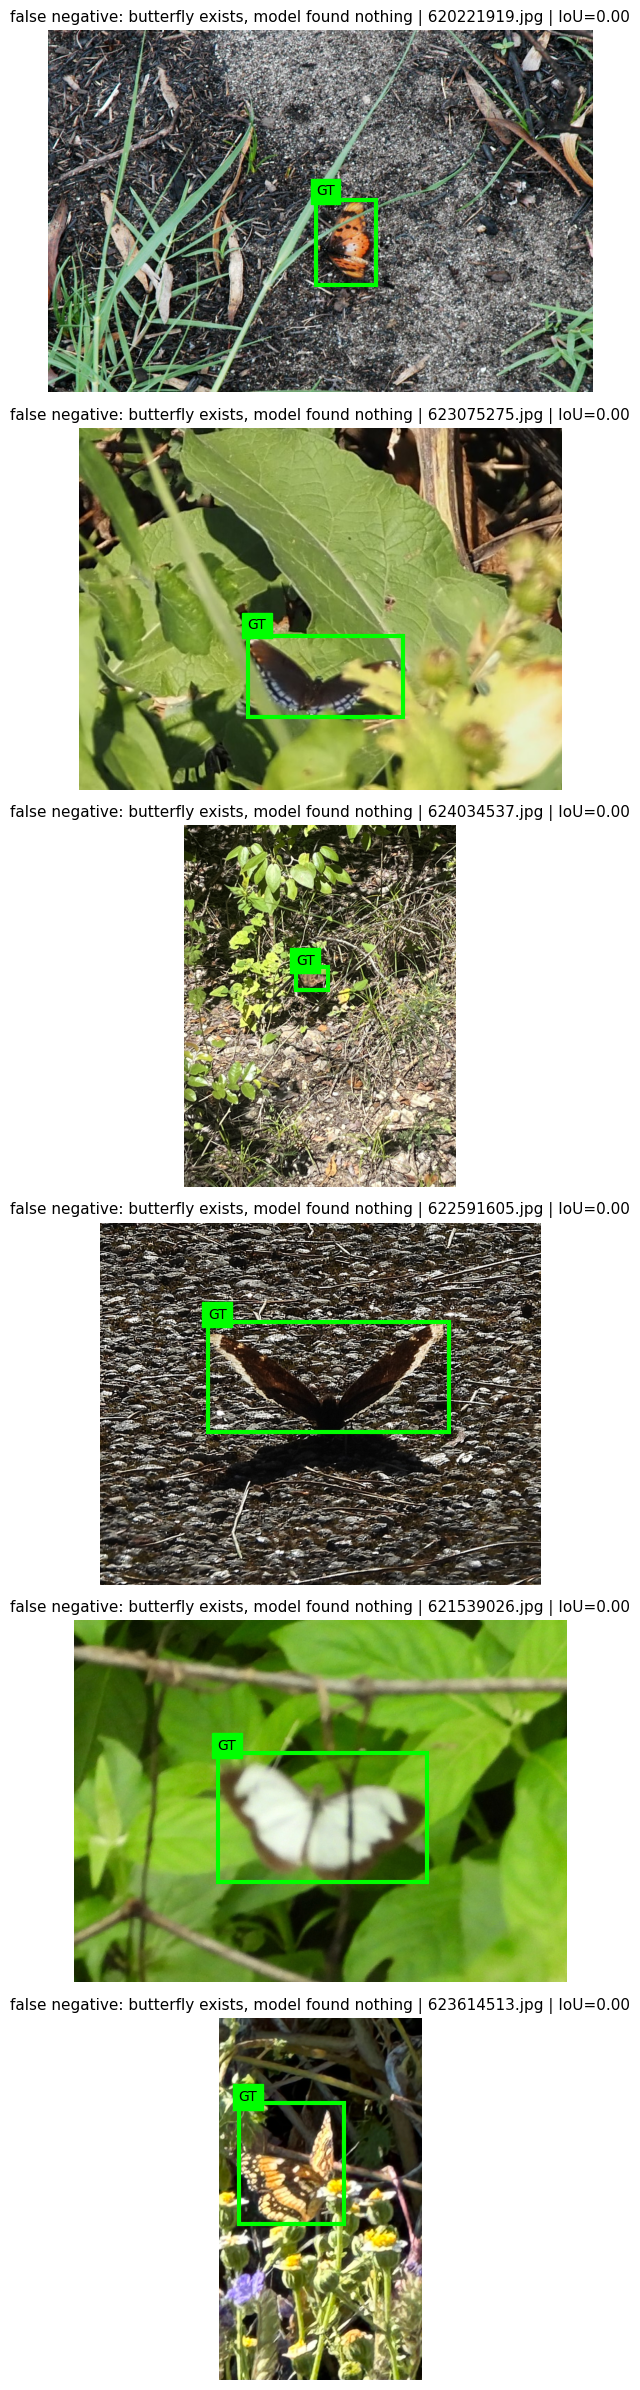

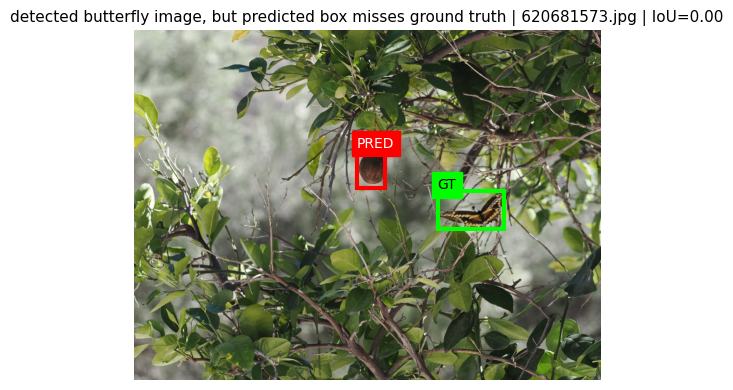

No good localized examples to show


In [13]:
bad_examples = eval_df.loc[
    ((eval_df["is_positive"]) & (eval_df["best_iou"].fillna(0) < IOU_THRESHOLD))
    | ((~eval_df["is_positive"]) & (eval_df["pred_has_box"]))
].head(6).copy()

detected_but_wrong_examples = eval_df.loc[
    (eval_df["is_positive"]) & (eval_df["pred_has_box"]) & (~eval_df["is_localized"])
].head(4).copy()

good_examples = eval_df.loc[eval_df["is_localized"]].head(4).copy()

print("Green box = ground truth")
print("Red box = model prediction")
print("bad examples:", len(bad_examples))
print("detected positive but wrong box:", len(detected_but_wrong_examples))
print("good localized examples:", len(good_examples))


def error_type(row):
    if row.is_positive and not row.pred_has_box:
        return "false negative: butterfly exists, model found nothing"
    if row.is_positive and row.pred_has_box and row.best_iou < IOU_THRESHOLD:
        return "poor localization: model found something, but not the butterfly"
    if (not row.is_positive) and row.pred_has_box:
        return "false positive: no butterfly, but model predicted one"
    return "other"


def draw_examples(example_df, title_prefix, empty_message):
    if len(example_df) == 0:
        print(empty_message)
        return

    fig, axes = plt.subplots(len(example_df), 1, figsize=(11, 4 * len(example_df)))
    if len(example_df) == 1:
        axes = [axes]

    for ax, row in zip(axes, example_df.itertuples(index=False)):
        image = Image.open(row.local_image).convert("RGB")
        ax.imshow(image)
        ax.axis("off")

        if row.gt_box is not None:
            x1, y1, x2, y2 = row.gt_box
            ax.add_patch(
                patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=3, edgecolor="lime", facecolor="none")
            )
            ax.text(x1, max(0, y1 - 10), "GT", color="black", fontsize=10, backgroundcolor="lime")

        for pred_box in row.pred_boxes:
            x1, y1, x2, y2 = pred_box
            ax.add_patch(
                patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=3, edgecolor="red", facecolor="none")
            )
            ax.text(x1, max(0, y1 - 10), "PRED", color="white", fontsize=10, backgroundcolor="red")

        iou_text = "n/a" if pd.isna(row.best_iou) else f"{row.best_iou:.2f}"
        row_title = title_prefix(row) if callable(title_prefix) else title_prefix
        ax.set_title(f"{row_title} | {Path(row.local_image).name} | IoU={iou_text}", fontsize=11)

    plt.tight_layout()
    plt.show()


draw_examples(bad_examples, error_type, "No bad examples to show")
draw_examples(
    detected_but_wrong_examples,
    lambda row: "detected butterfly image, but predicted box misses ground truth",
    "No detected-but-wrong examples to show",
)
draw_examples(good_examples, lambda row: "good example: model matches ground truth", "No good localized examples to show")


## Вывод

1. loss не показывает стабильного снижения;
2. качество на тесте остаётся низким;
3. на визуальных примерах видно много промахов и плохую локализацию.
